In [5]:
"""
Metric Derivation for Charged Galactic Wormhole
Eq. (3): ds² = -(1 + Q²/r²)dt² + (1 - b(r)/r + Q²/r²)⁻¹dr² + r²(dθ² + sin²θ dφ²)
"""

'\nMetric Derivation for Charged Galactic Wormhole\nEq. (3): ds² = -(1 + Q²/r²)dt² + (1 - b(r)/r + Q²/r²)⁻¹dr² + r²(dθ² + sin²θ dφ²)\n'

In [6]:
import sys; sys.path.append('..')
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import yaml

In [8]:
with open('../config/params.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

In [9]:
rho_s = config['dark_matter']['rho_s']
r_s = config['dark_matter']['r_s']
C1 = config['wormhole']['C1']
Q = config['wormhole']['Q']

In [10]:
from src.dark_matter import DarkMatterProfile
from src.shape_function import ShapeFunction
from src.metric import ChargedWormholeMetric

In [11]:
dm = DarkMatterProfile(rho_s, r_s)
sf = ShapeFunction(rho_s, r_s, C1, Q)
metric = ChargedWormholeMetric(sf)

In [16]:
r, theta = sp.symbols('r theta', real=True)

# Direct symbolic expression for b(r)
b_sym = -8 * r_s * (r**2 + 2*r*r_s + 2*r_s**2) * sp.exp(-r/r_s) * sp.pi * rho_s + C1

print("Metric components from Eq. (3):")
print(f"g_tt = {-(1 + Q**2/r**2)}")
print(f"g_rr = {1/(1 - b_sym/r + Q**2/r**2)}")

Metric components from Eq. (3):
g_tt = -1 - 0.01/r**2
g_rr = 1/(1 - 0.05*pi*(-8.0*r**2 - 16.0*r - 16.0)*exp(-1.0*r)/r + 0.01/r**2)


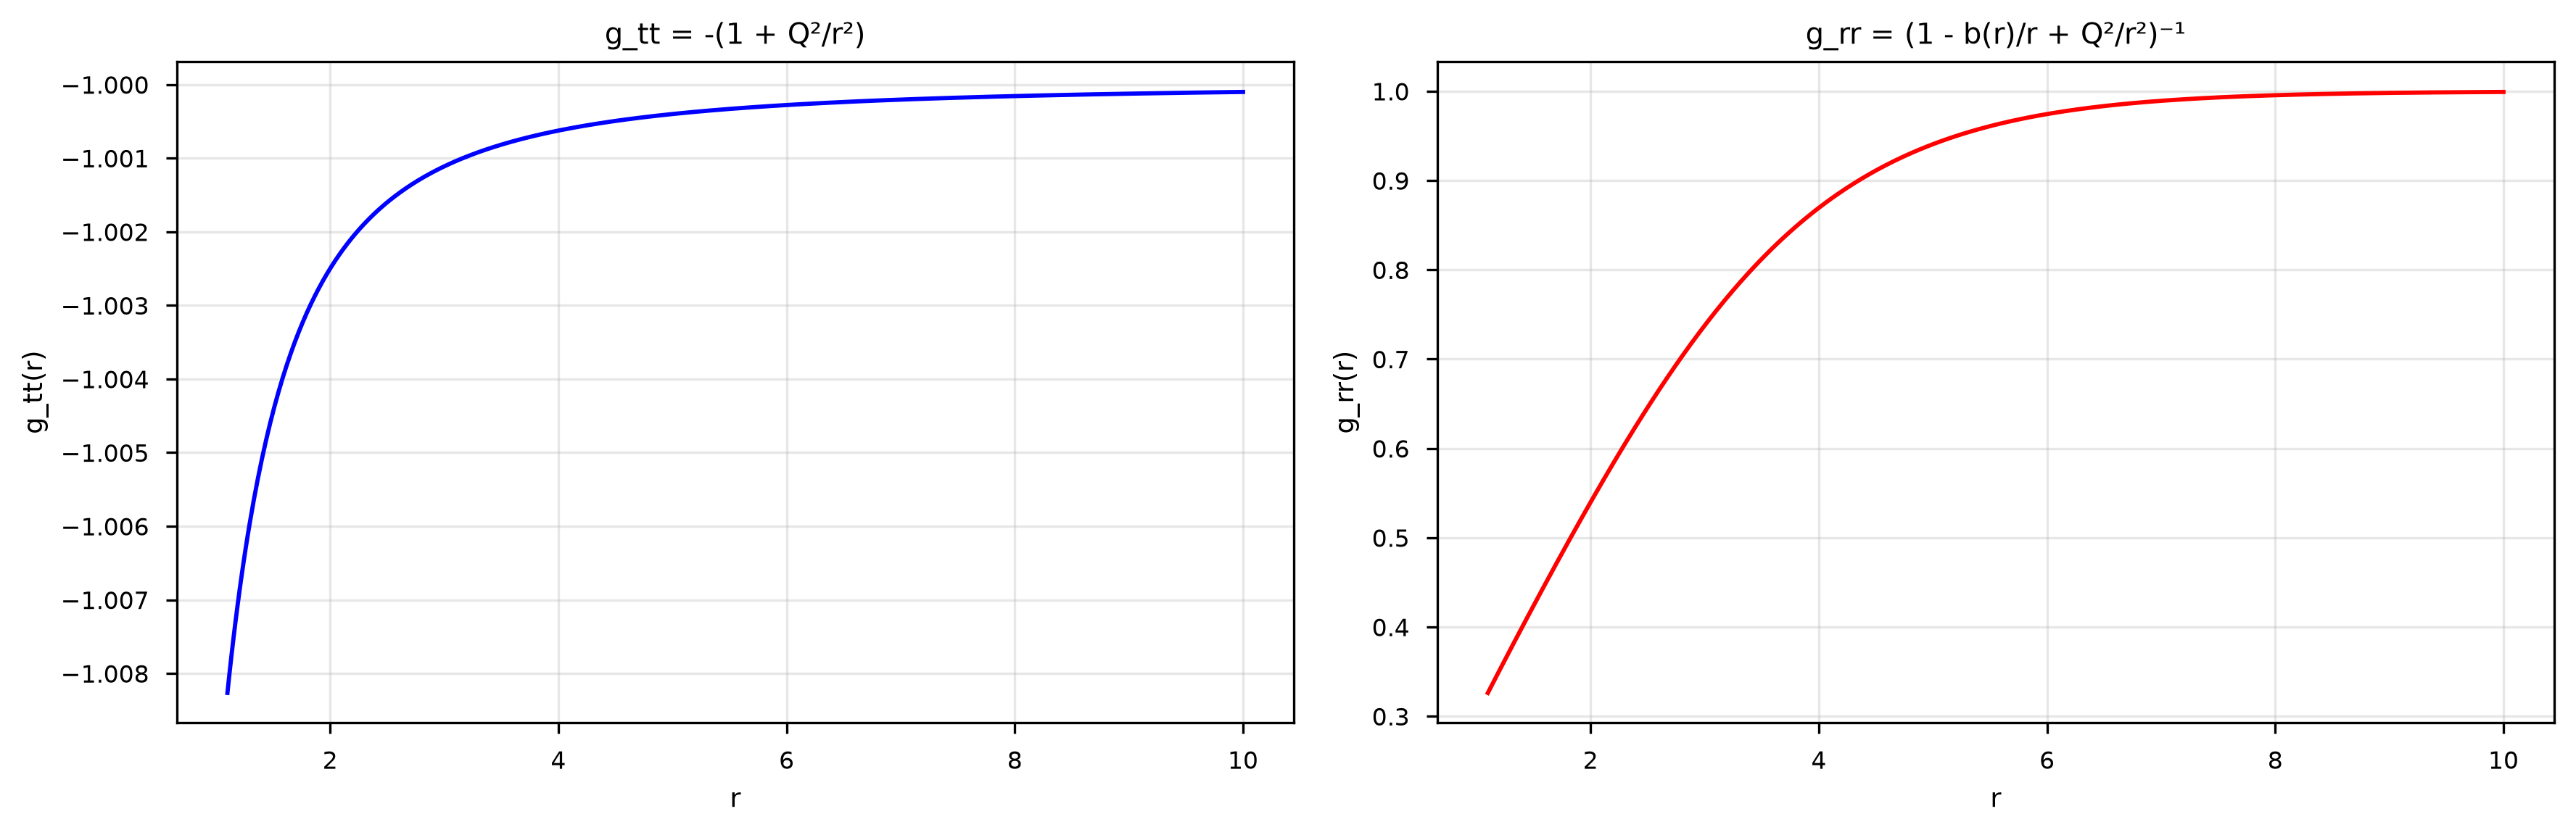

In [17]:
r_values = np.linspace(1.1, 10, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(r_values, metric.g_tt(r_values), 'b-')
axes[0].set_xlabel('r'); axes[0].set_ylabel('g_tt(r)')
axes[0].set_title('g_tt = -(1 + Q²/r²)'); axes[0].grid(True, alpha=0.3)
axes[1].plot(r_values, metric.g_rr(r_values), 'r-')
axes[1].set_xlabel('r'); axes[1].set_ylabel('g_rr(r)')
axes[1].set_title('g_rr = (1 - b(r)/r + Q²/r²)⁻¹'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()